# Dynamika pohybu vozidla

Dynamika sa zaoberá príčinami pohybu, teda silami ktoré pohyb spôsobujú alebo brzdia. V tomto notebooku aplikujeme Newtonove zákony na reálne vozidlo a skúmame vzťah medzi silou, hmotnosťou a zrýchlením.

## Teoretický základ

Na pohybujúce sa vozidlo pôsobia tri hlavné sily:

**Hnacia sila motora:**
$$F_{motor} = \frac{P}{v}$$

**Aerodynamický odpor:**
$$F_{vzduch} = \frac{1}{2} \cdot \rho \cdot C_d \cdot A \cdot v^2$$

**Valivý odpor:**
$$F_{valivý} = \mu \cdot m \cdot g$$

**Výsledné zrýchlenie** podľa Newtonovho druhého zákona:
$$a = \frac{F_{motor} - F_{vzduch} - F_{valivý}}{m}$$

Vozidlo dosiahne maximálnu rýchlosť keď $F_{motor} = F_{vzduch} + F_{valivý}$.

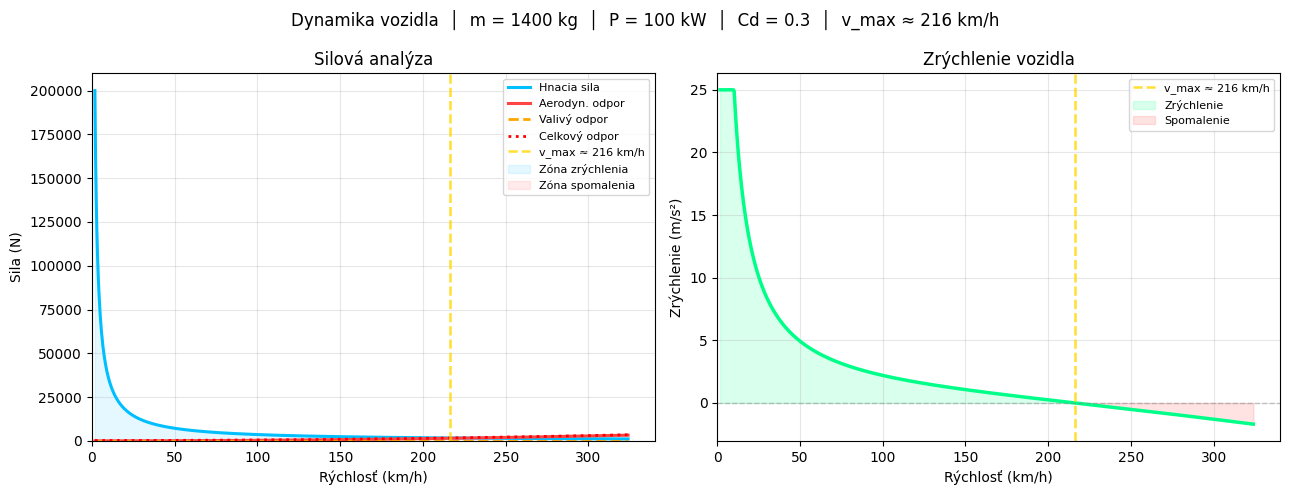

Hmotnosť:            1400 kg
Výkon motora:        100 kW
Koef. odporu Cd:     0.3
Valivý odpor μ:      0.015
Maximálna rýchlosť:  ≈ 216 km/h


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Fyzikálne konštanty
RHO = 1.225   # hustota vzduchu [kg/m³]
G   = 9.81    # gravitačné zrýchlenie [m/s²]
A   = 2.2     # čelná plocha vozidla [m²]

# Parametre vozidla
m    = 1400    # hmotnosť vozidla v kg
P_kW = 100     # výkon motora v kW
Cd   = 0.30    # koeficient aerodynamického odporu
mu   = 0.015   # koeficient valivého odporu

P = P_kW * 1000
v = np.linspace(0.5, 90, 800)
v_kmh = v * 3.6

# Výpočet síl
F_motor  = P / v
F_vzduch = 0.5 * RHO * Cd * A * v**2
F_valivý = mu * m * G * np.ones_like(v)
F_odpor  = F_vzduch + F_valivý
F_celk   = F_motor - F_odpor
a        = np.clip(F_celk / m, -25, 25)

# Maximálna rýchlosť je kde sa sily vyrovnajú
idx_vmax = np.argmin(np.abs(F_celk))
v_max    = v_kmh[idx_vmax]

# Graf síl
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(v_kmh, F_motor,  color='#00BFFF', lw=2.2, label='Hnacia sila')
ax1.plot(v_kmh, F_vzduch, color='#FF4444', lw=2.2, label='Aerodyn. odpor')
ax1.plot(v_kmh, F_valivý, color='#FFA500', lw=2.0, linestyle='--', label='Valivý odpor')
ax1.plot(v_kmh, F_odpor,  color='#FF0000', lw=2.0, linestyle=':', label='Celkový odpor')
ax1.axvline(x=v_max, color='#FFD700', lw=1.8, linestyle='--',
            alpha=0.8, label=f'v_max ≈ {v_max:.0f} km/h')
ax1.fill_between(v_kmh, F_motor, F_odpor,
                 where=(F_motor >= F_odpor),
                 alpha=0.10, color='#00BFFF', label='Zóna zrýchlenia')
ax1.fill_between(v_kmh, F_motor, F_odpor,
                 where=(F_motor < F_odpor),
                 alpha=0.10, color='#FF4444', label='Zóna spomalenia')
ax1.set_xlabel('Rýchlosť (km/h)')
ax1.set_ylabel('Sila (N)')
ax1.set_title('Silová analýza')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)
ax1.set_xlim(left=0)

# Graf zrýchlenia
ax2.plot(v_kmh, a, color='#00FF88', lw=2.5)
ax2.axhline(y=0, color='gray', lw=1, linestyle='--', alpha=0.4)
ax2.axvline(x=v_max, color='#FFD700', lw=1.8, linestyle='--',
            alpha=0.8, label=f'v_max ≈ {v_max:.0f} km/h')
ax2.fill_between(v_kmh, a, 0, where=(a >= 0),
                 alpha=0.15, color='#00FF88', label='Zrýchlenie')
ax2.fill_between(v_kmh, a, 0, where=(a < 0),
                 alpha=0.15, color='#FF4444', label='Spomalenie')
ax2.set_xlabel('Rýchlosť (km/h)')
ax2.set_ylabel('Zrýchlenie (m/s²)')
ax2.set_title('Zrýchlenie vozidla')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=0)

fig.suptitle(
    f'Dynamika vozidla  │  m = {m} kg  │  P = {P_kW} kW  │  '
    f'Cd = {Cd}  │  v_max ≈ {v_max:.0f} km/h',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f'Hmotnosť:            {m} kg')
print(f'Výkon motora:        {P_kW} kW')
print(f'Koef. odporu Cd:     {Cd}')
print(f'Valivý odpor μ:      {mu}')
print(f'Maximálna rýchlosť:  ≈ {v_max:.0f} km/h')

![Dynamika pohybu vozidla](_images/dynamikav.png)
*Obr. Silová analýza a zrýchlenie vozidla*

## Záver

- Hnacia sila klesá s rastúcou rýchlosťou, aerodynamický odpor naopak rastie kvadraticky
- Maximálna rýchlosť nastane keď sa hnacia sila a celkový odpor vyrovnajú
- Ťažšie vozidlo dosahuje nižšie zrýchlenie pri rovnakom výkone motora
- Aerodynamický odpor pri vysokých rýchlostiach dominuje nad ostatnými odpormi